In [1]:
import pandas as pd
import numpy as np
import pyarrow.parquet as pq

import xgboost as xgb


# Importing the libraries
import polars as pl
import os
import sys
import altair as alt
import vegafusion as vf
import sklearn
import time
from datetime import date, datetime, timedelta
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder 

import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV

In [2]:
#table = pq.read_table('C:/Users/J.Heuvelmans/OneDrive - Brain Research Center/Documenten/EAISI/2024Supermarket/Code/data/interim/Prepped_data_20241018.parquet')
df_import = pd.read_parquet('C:/Users/J.Heuvelmans/OneDrive - Brain Research Center/Documenten/EAISI/2024Supermarket/Code/data/processed/Aggregated_data_20241019.parquet', engine='pyarrow')

# Specify the columns you want to load to reduce memory usage
#columns_to_load = ['store_nbr', 'item_nbr', 'date', 'unit_sales', 'week_number_cum', 'onpromotion', 'perishable']  # Replace with your column names
#table = pq.read_table('C:/Users/J.Heuvelmans/OneDrive - Brain Research Center/Documenten/EAISI/2024Supermarket/Code/data/interim/Prepped_data_20241018.parquet', columns=columns_to_load)

# Convert to Pandas DataFrame if needed
#df = table.to_pandas()
df = df_import



In [3]:
df.head()

,store_nbr,item_nbr,year,week_number_cum,unit_sales,onpromotion,holiday_local_count,holiday_regional_count,holiday_national_count,date,store_type,store_cluster,item_family,item_class,perishable,store_status,item_status
0,1,96995,2013,1,0.0,0,0,0,1,2013-01-02,D,13,GROCERY I,1093,0,0,3
1,1,96995,2013,2,2.0,0,0,0,1,2013-01-07,D,13,GROCERY I,1093,0,0,1
2,1,96995,2013,3,3.0,0,0,0,0,2013-01-14,D,13,GROCERY I,1093,0,0,1
3,1,96995,2013,4,2.0,0,0,0,0,2013-01-21,D,13,GROCERY I,1093,0,0,1
4,1,96995,2013,5,2.0,0,0,0,0,2013-01-28,D,13,GROCERY I,1093,0,0,1


In [4]:
df.head()

,store_nbr,item_nbr,year,week_number_cum,unit_sales,onpromotion,holiday_local_count,holiday_regional_count,holiday_national_count,date,store_type,store_cluster,item_family,item_class,perishable,store_status,item_status
0,1,96995,2013,1,0.0,0,0,0,1,2013-01-02,D,13,GROCERY I,1093,0,0,3
1,1,96995,2013,2,2.0,0,0,0,1,2013-01-07,D,13,GROCERY I,1093,0,0,1
2,1,96995,2013,3,3.0,0,0,0,0,2013-01-14,D,13,GROCERY I,1093,0,0,1
3,1,96995,2013,4,2.0,0,0,0,0,2013-01-21,D,13,GROCERY I,1093,0,0,1
4,1,96995,2013,5,2.0,0,0,0,0,2013-01-28,D,13,GROCERY I,1093,0,0,1


In [5]:
df.describe()

,store_nbr,item_nbr,year,week_number_cum,unit_sales,onpromotion,holiday_local_count,holiday_regional_count,holiday_national_count,date,store_cluster,item_class,perishable,store_status,item_status
count,2.879461e+07,2.879461e+07,2.879461e+07,2.879461e+07,2.879461e+07,2.879461e+07,2.879461e+07,2.879461e+07,2.879461e+07,28794612,2.879461e+07,2.879461e+07,2.879461e+07,2.879461e+07,2.879461e+07
mean,2.657143e+01,1.103206e+06,2.014843e+03,1.215000e+02,2.145166e+01,1.527600e-01,2.951594e-02,2.656434e-03,4.917355e-01,2015-04-23 12:11:54.049592064,8.309524e+00,2.141370e+03,2.400282e-01,1.070445e-01,3.182379e+00
min,1.000000e+00,9.699500e+04,2.013000e+03,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2013-01-02 00:00:00,1.000000e+00,1.002000e+03,0.000000e+00,0.000000e+00,1.000000e+00
25%,1.100000e+01,5.869670e+05,2.014000e+03,6.100000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2014-02-24 00:00:00,4.000000e+00,1.040000e+03,0.000000e+00,0.000000e+00,1.000000e+00
50%,2.550000e+01,1.083152e+06,2.015000e+03,1.215000e+02,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2015-04-23 12:00:00,7.500000e+00,2.116000e+03,0.000000e+00,0.000000e+00,1.000000e+00
75%,4.100000e+01,1.458848e+06,2.016000e+03,1.820000e+02,2.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2016-06-20 00:00:00,1.300000e+01,3.004000e+03,0.000000e+00,0.000000e+00,3.000000e+00
max,5.400000e+01,2.126842e+06,2.017000e+03,2.420000e+02,8.944000e+04,7.000000e+00,2.000000e+00,1.000000e+00,6.000000e+00,2017-08-14 00:00:00,1.700000e+01,7.780000e+03,1.000000e+00,4.000000e+00,9.000000e+00
std,1.669352e+01,6.017957e+05,1.345382e+00,6.985879e+01,6.559453e+01,7.531557e-01,2.157570e-01,5.147211e-02,1.013307e+00,NaN,4.823001e+00,1.378002e+03,4.271003e-01,5.407022e-01,3.159682e+00


In [6]:
# # Creating lagged and rolling mean features for each item-store combination
# def add_lagged_features(group):
#     group = group.sort_values('week_number_cum')  # Ensure sorting by date
#     group['Predicted Last'] = group['unit_sales'].shift(2)  # Shift by 2 days for lag
    
#     return group


In [65]:
def add_lagged_features(group, max_lag=26):
    # Ensure sorting by week_number_cum
    group = group.sort_values('week_number_cum')
    
    # Generate lagged features up to max_lag weeks back
    for lag in range(1, max_lag + 1):
        group[f'unit_sales_lag_{lag}'] = group['unit_sales'].shift(lag)
    
    return group

In [66]:

df_lag = df.groupby(['item_nbr', 'store_nbr'], group_keys=False).apply(add_lagged_features).reset_index(drop=True)

C:\Users\J.Heuvelmans\AppData\Local\Temp\ipykernel_14324\4191656054.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_lag = df.groupby(['item_nbr', 'store_nbr'], group_keys=False).apply(add_lagged_features).reset_index(drop=True)


In [67]:
df_lag.head()

,store_nbr,item_nbr,year,week_number_cum,unit_sales,onpromotion,holiday_local_count,holiday_regional_count,holiday_national_count,date,...,unit_sales_lag_17,unit_sales_lag_18,unit_sales_lag_19,unit_sales_lag_20,unit_sales_lag_21,unit_sales_lag_22,unit_sales_lag_23,unit_sales_lag_24,unit_sales_lag_25,unit_sales_lag_26
0,1,96995,2013,1,0.0,0,0,0,1,2013-01-02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,96995,2013,2,2.0,0,0,0,1,2013-01-07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,96995,2013,3,3.0,0,0,0,0,2013-01-14,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,96995,2013,4,2.0,0,0,0,0,2013-01-21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,96995,2013,5,2.0,0,0,0,0,2013-01-28,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [68]:
df = df_lag

In [69]:
df.head()

,store_nbr,item_nbr,year,week_number_cum,unit_sales,onpromotion,holiday_local_count,holiday_regional_count,holiday_national_count,date,...,unit_sales_lag_17,unit_sales_lag_18,unit_sales_lag_19,unit_sales_lag_20,unit_sales_lag_21,unit_sales_lag_22,unit_sales_lag_23,unit_sales_lag_24,unit_sales_lag_25,unit_sales_lag_26
0,1,96995,2013,1,0.0,0,0,0,1,2013-01-02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,96995,2013,2,2.0,0,0,0,1,2013-01-07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,96995,2013,3,3.0,0,0,0,0,2013-01-14,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,96995,2013,4,2.0,0,0,0,0,2013-01-21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,96995,2013,5,2.0,0,0,0,0,2013-01-28,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [70]:
df_train = df[(df['week_number_cum'] > 138) & (df['week_number_cum'] <= 190)]
#df_train = df[df['week_number_cum'] <= 190]
df_test = df[(df['week_number_cum'] > 190) & (df['week_number_cum'] <= 216)]
#df_test = df[df['week_number_cum'] == 192]
df_validate = df[df['week_number_cum'] > 216]

In [71]:
# # Lijst met features maken
# list_features = [col for col in df.columns if col not in ['date']]

# # Lijst voor het opslaan van alle df_test dataframes
# df_test_list = []

# # Loop door de weken in de testset
# for i in range(192, 217):  # Van week 192 tot en met 216
#     # Train en test set splitsen
#     df_train = df[(df['week_number_cum'] > (i - 54)) & (df['week_number_cum'] <= (i - 2))]
#     df_test = df[df['week_number_cum'] == i].copy()  # Maak expliciet een kopie van de slice

#     # Controleer of er voldoende gegevens zijn
#     if df_train.empty or df_test.empty:
#         print(f"Niet genoeg data voor week {i}.")
#         continue

#     # Bereid de invoer en uitvoer voor de trainings- en testset
#     X_train = df_train[list_features]
#     y_train = df_train['unit_sales']
#     X_test = df_test[list_features]
#     y_test = df_test['unit_sales']

#     # Model initialiseren en trainen
#     model = xgb.XGBRegressor(objective='reg:squarederror', enable_categorical=True)
#     model.fit(X_train, y_train)

#     # Voorspelling maken
#     y_pred = model.predict(X_test)
#     y_pred[y_pred < 0] = 0  # Zorg ervoor dat voorspellingen niet negatief zijn

#     # DF uitbreiden met voorspellingen en bias, gebruik .loc[] om wijzigingen veilig door te voeren
#     df_test.loc[:, 'y_pred'] = y_pred
#     df_test.loc[:, 'bias'] = df_test['unit_sales'] - df_test['y_pred']

#     # Voeg df_test toe aan de lijst
#     df_test_list.append(df_test)

#     # Bereken de nauwkeurigheid
#     accuracy = (1 - (np.mean(np.abs(y_test - y_pred)) / np.mean(y_test))) * 100

#     # Bereken de bias
#     residuals = y_test - y_pred  # Bereken de residuen
#     bias = np.mean(residuals)

#     # Bereken de standaarddeviatie van de residuen
#     sd_bias = np.std(residuals)
#     print(f'Accuracy {i}: {accuracy:.2f}%, Bias {i}: {bias:.2f} with Standard Deviation of Bias {i}: {sd_bias:.2f}')

# # Concateneer alle dataframes in de lijst tot één dataframe
# final_df_test = pd.concat(df_test_list, ignore_index=True)

# # Controleer de resulterende dataframe
# print(final_df_test)


In [72]:
#final_df_test

In [73]:
list_features =[col for col in df.columns if col not in ['unit_sales', 'date', 'unit_sales_lag_1']]
list_features

['store_nbr',
 'item_nbr',
 'year',
 'week_number_cum',
 'onpromotion',
 'holiday_local_count',
 'holiday_regional_count',
 'holiday_national_count',
 'store_type',
 'store_cluster',
 'item_family',
 'item_class',
 'perishable',
 'store_status',
 'item_status',
 'unit_sales_lag_2',
 'unit_sales_lag_3',
 'unit_sales_lag_4',
 'unit_sales_lag_5',
 'unit_sales_lag_6',
 'unit_sales_lag_7',
 'unit_sales_lag_8',
 'unit_sales_lag_9',
 'unit_sales_lag_10',
 'unit_sales_lag_11',
 'unit_sales_lag_12',
 'unit_sales_lag_13',
 'unit_sales_lag_14',
 'unit_sales_lag_15',
 'unit_sales_lag_16',
 'unit_sales_lag_17',
 'unit_sales_lag_18',
 'unit_sales_lag_19',
 'unit_sales_lag_20',
 'unit_sales_lag_21',
 'unit_sales_lag_22',
 'unit_sales_lag_23',
 'unit_sales_lag_24',
 'unit_sales_lag_25',
 'unit_sales_lag_26']

In [74]:
X_train = df_train[list_features]
y_train = df_train['unit_sales']

X_test = df_test[list_features]
y_test = df_test['unit_sales']

In [75]:
from sklearn.metrics import make_scorer, mean_absolute_percentage_error

# Define the model
model = xgb.XGBRegressor(objective='reg:squarederror', enable_categorical=True)

# Define the MAPE scoring function
mape_scorer = make_scorer(mean_absolute_percentage_error, greater_is_better=False)

# Set up a simplified parameter grid for tuning
param_grid = {
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200],
    'max_depth': [3, 5]
}

# Set up GridSearchCV with MAPE scoring
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, 
                           cv=3,  # 3-fold cross-validation
                           scoring=mape_scorer,  # Use MAPE as the scoring metric
                           verbose=1, 
                           n_jobs=-1)

# Fit GridSearchCV
grid_search.fit(X_train, y_train)

# Get the best parameters and model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print("Best Parameters:", best_params)



Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}


In [76]:
model = xgb.XGBRegressor(objective='reg:squarederror', 
                              enable_categorical=True,
                              learning_rate=0.05, 
                              max_depth=5, 
                              n_estimators=100)

model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [77]:
feature_importance = model.feature_importances_
feature_importance

array([0.017712  , 0.01279459, 0.00554466, 0.0064132 , 0.00245182,
       0.        , 0.00378652, 0.01675408, 0.01333445, 0.00656157,
       0.02299383, 0.01372946, 0.        , 0.        , 0.00899835,
       0.33362326, 0.07728646, 0.04039006, 0.05104515, 0.01887056,
       0.03008513, 0.01642768, 0.02958305, 0.03433036, 0.03729852,
       0.0067503 , 0.02871753, 0.01950823, 0.00510984, 0.01654672,
       0.02249496, 0.01907087, 0.01842845, 0.00815291, 0.00650715,
       0.01022511, 0.01584798, 0.00609237, 0.0081799 , 0.00835288],
      dtype=float32)

In [ ]:
y_pred = model.predict(X_test)
y_pred[y_pred < 0] = 0
y_pred

In [60]:
df_test['y_pred'] = y_pred
df_test

C:\Users\J.Heuvelmans\AppData\Local\Temp\ipykernel_14324\3497537248.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['y_pred'] = y_pred


,store_nbr,item_nbr,year,week_number_cum,unit_sales,onpromotion,holiday_local_count,holiday_regional_count,holiday_national_count,date,...,unit_sales_lag_3,unit_sales_lag_4,unit_sales_lag_5,unit_sales_lag_6,unit_sales_lag_7,unit_sales_lag_8,unit_sales_lag_9,unit_sales_lag_10,y_pred,bias
190,1,96995,2016,191,0.0,0,0,0,0,2016-08-22,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.243301,-2.775539
191,1,96995,2016,192,0.0,0,0,0,0,2016-08-29,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.243301,-2.775539
192,1,96995,2016,193,0.0,0,0,0,0,2016-09-05,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.243301,-2.775539
193,1,96995,2016,194,0.0,0,0,0,0,2016-09-12,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.243301,-2.775539
194,1,96995,2016,195,0.0,0,0,0,0,2016-09-19,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.243301,-2.775539
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28794581,54,2126842,2017,212,0.0,0,0,0,0,2017-01-16,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.114493,0.000000
28794582,54,2126842,2017,213,0.0,0,0,0,0,2017-01-23,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.114493,0.000000
28794583,54,2126842,2017,214,0.0,0,0,0,0,2017-01-30,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.114493,0.000000
28794584,54,2126842,2017,215,0.0,0,0,0,0,2017-02-06,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.114493,0.000000


In [61]:
df_test['bias'] = df_test['unit_sales'] - df_test['y_pred']
df_test

C:\Users\J.Heuvelmans\AppData\Local\Temp\ipykernel_14324\2725599386.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['bias'] = df_test['unit_sales'] - df_test['y_pred']


,store_nbr,item_nbr,year,week_number_cum,unit_sales,onpromotion,holiday_local_count,holiday_regional_count,holiday_national_count,date,...,unit_sales_lag_3,unit_sales_lag_4,unit_sales_lag_5,unit_sales_lag_6,unit_sales_lag_7,unit_sales_lag_8,unit_sales_lag_9,unit_sales_lag_10,y_pred,bias
190,1,96995,2016,191,0.0,0,0,0,0,2016-08-22,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.243301,-3.243301
191,1,96995,2016,192,0.0,0,0,0,0,2016-08-29,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.243301,-3.243301
192,1,96995,2016,193,0.0,0,0,0,0,2016-09-05,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.243301,-3.243301
193,1,96995,2016,194,0.0,0,0,0,0,2016-09-12,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.243301,-3.243301
194,1,96995,2016,195,0.0,0,0,0,0,2016-09-19,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.243301,-3.243301
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28794581,54,2126842,2017,212,0.0,0,0,0,0,2017-01-16,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.114493,-0.114493
28794582,54,2126842,2017,213,0.0,0,0,0,0,2017-01-23,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.114493,-0.114493
28794583,54,2126842,2017,214,0.0,0,0,0,0,2017-01-30,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.114493,-0.114493
28794584,54,2126842,2017,215,0.0,0,0,0,0,2017-02-06,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.114493,-0.114493


In [62]:
# Calculate MAPE (Mean Absolute Percentage Error)
mape = (np.mean(np.abs(y_test - y_pred))) / np.mean(y_test) * 100
print(f'MAPE: {mape:.2f}%')

# Calculate Accuracy 
#accuracy = np.mean(1 - (np.abs(y_test[non_zero_indices] - y_pred[non_zero_indices]) / y_test[non_zero_indices])) * 100
accuracy = (1 - (np.mean(np.abs(y_test - y_pred)) / np.mean(y_test))) * 100
print(f'Accuracy: {accuracy:.2f}%')

# Calculate the residuals
residuals = y_test - y_pred

# Calculate Bias
#bias = np.mean(residuals)
bias = np.mean(df_test['bias'])
print(f'Bias: {bias:.2f}')

# Calculate Standard Deviation of the residuals
# sd_bias = np.std(residuals)
sd_bias = np.std(df_test['bias'])
print(f'Standard Deviation of Bias: {sd_bias:.2f}')

MAPE: 36.14%
Accuracy: 63.86%
Bias: 0.71
Standard Deviation of Bias: 67.34


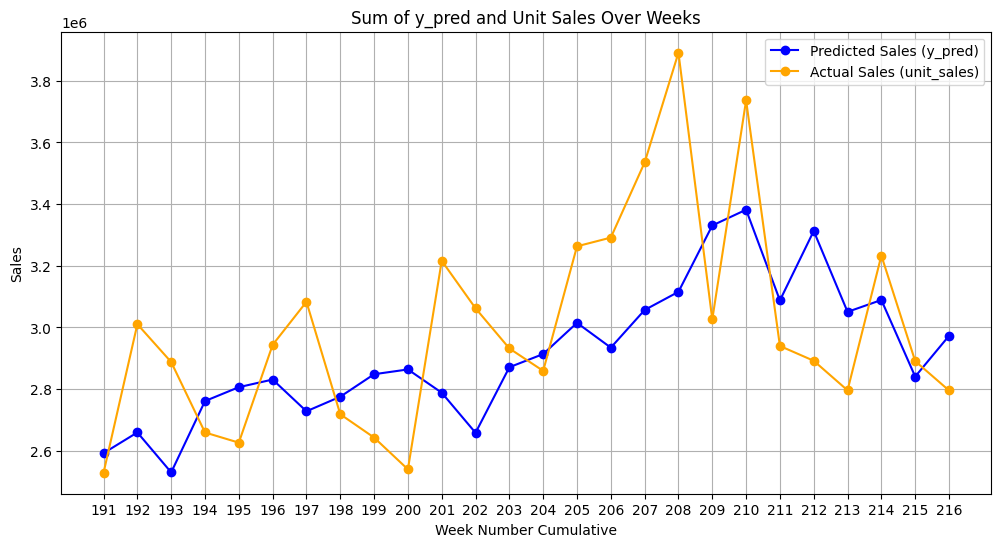

In [63]:
# Step 1: Group by 'week_number_cum' and calculate the sum
grouped_df = df_test.groupby('week_number_cum')[['y_pred', 'unit_sales']].sum().reset_index()

# Step 2: Plot the results
plt.figure(figsize=(12, 6))
plt.plot(grouped_df['week_number_cum'], grouped_df['y_pred'], marker='o', label='Predicted Sales (y_pred)', color='blue')
plt.plot(grouped_df['week_number_cum'], grouped_df['unit_sales'], marker='o', label='Actual Sales (unit_sales)', color='orange')

# Add titles and labels
plt.title('Sum of y_pred and Unit Sales Over Weeks')
plt.xlabel('Week Number Cumulative')
plt.ylabel('Sales')
plt.xticks(grouped_df['week_number_cum'])  # Set x-ticks to show all weeks
plt.legend()
plt.grid()

# Show the plot
plt.show()

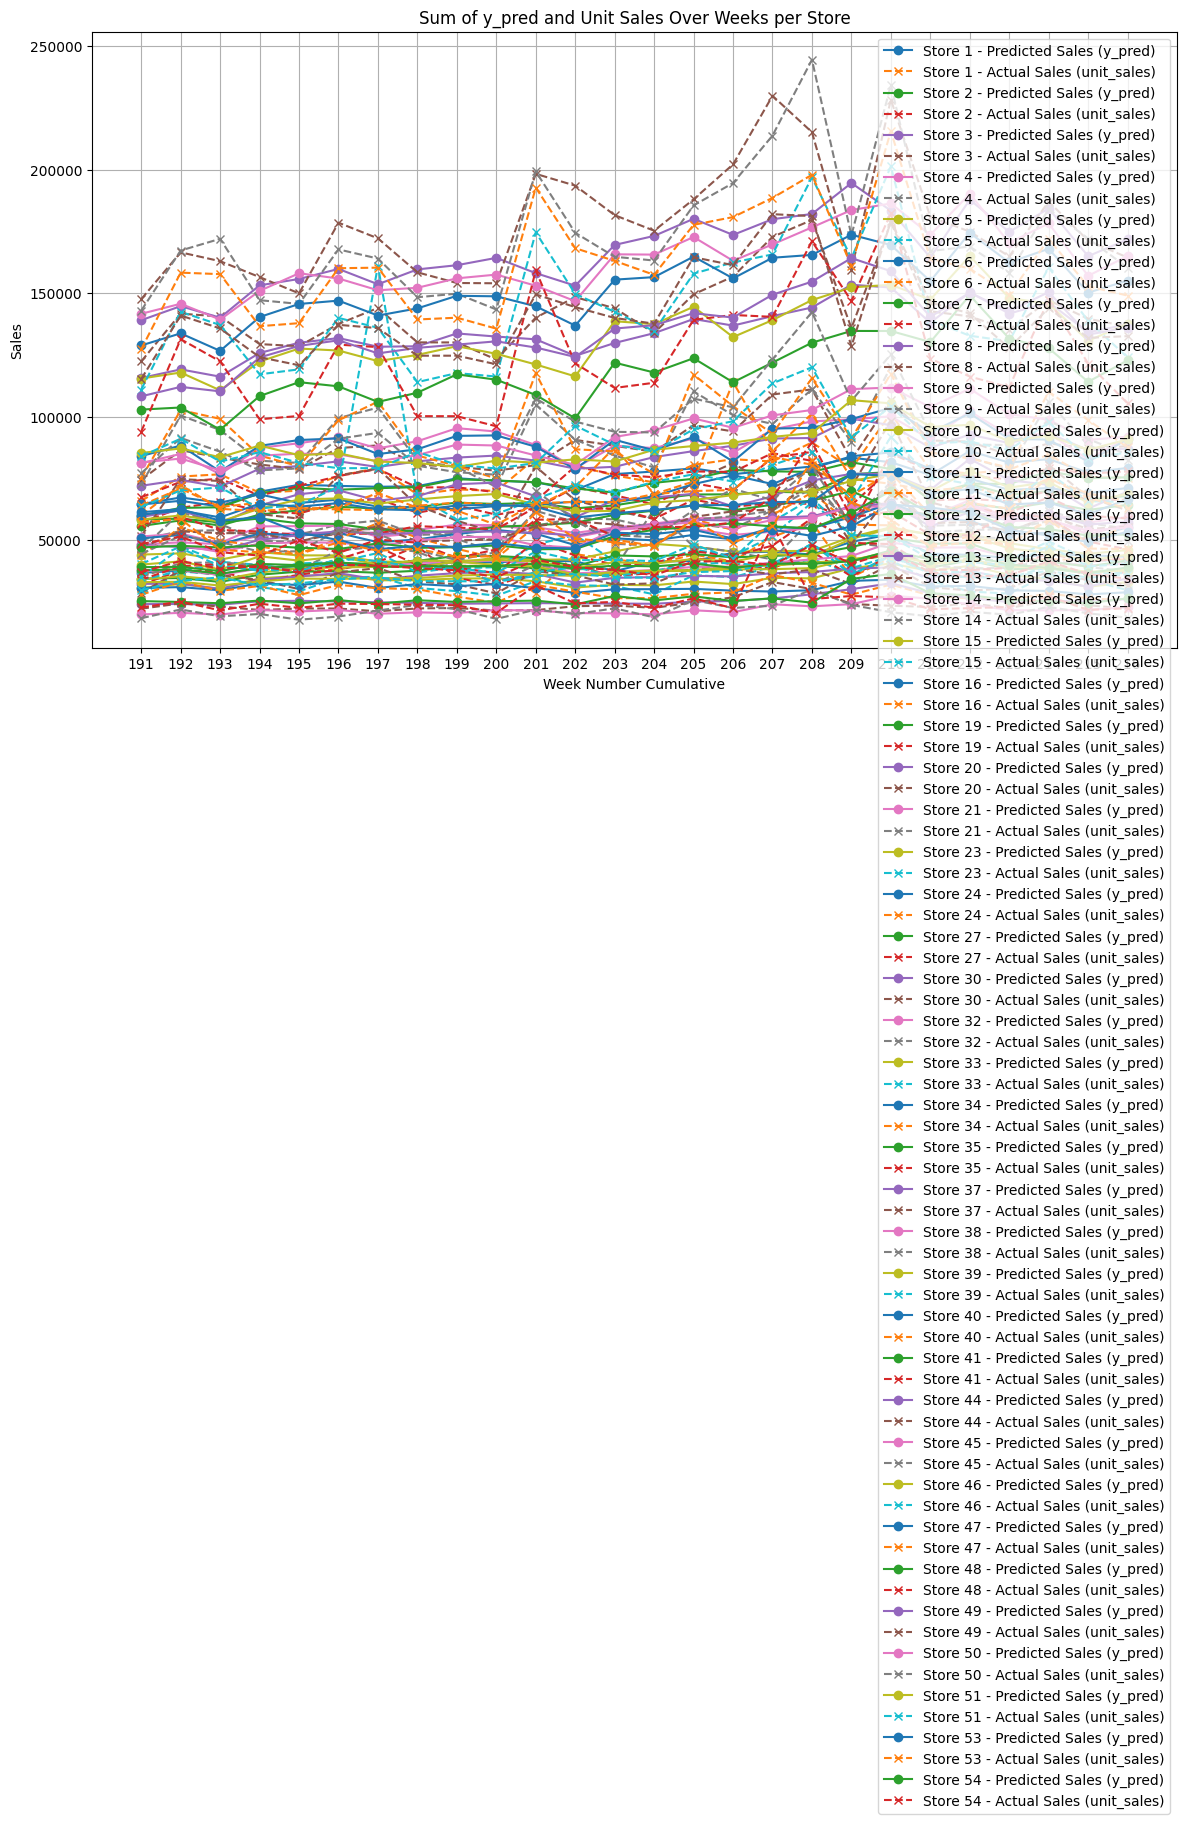

In [64]:
# Step 1: Group by 'store_nbr' and 'week_number_cum' and calculate the sum
grouped_df = df_test.groupby(['store_nbr', 'week_number_cum'])[['y_pred', 'unit_sales']].sum().reset_index()

# Step 2: Plot the results for each store
store_nbrs = grouped_df['store_nbr'].unique()  # Get unique store numbers

plt.figure(figsize=(14, 8))

# Create a plot for each store
for store in store_nbrs:
    store_data = grouped_df[grouped_df['store_nbr'] == store]
    plt.plot(store_data['week_number_cum'], store_data['y_pred'], marker='o', label=f'Store {store} - Predicted Sales (y_pred)')
    plt.plot(store_data['week_number_cum'], store_data['unit_sales'], marker='x', label=f'Store {store} - Actual Sales (unit_sales)', linestyle='--')

# Add titles and labels
plt.title('Sum of y_pred and Unit Sales Over Weeks per Store')
plt.xlabel('Week Number Cumulative')
plt.ylabel('Sales')
plt.xticks(store_data['week_number_cum'])  # Set x-ticks to show all weeks
plt.legend()
plt.grid()

# Show the plot
plt.show()